### **DYNAMIC PRICING ENGINE**

**1. Problem Statement**

1.Businesses facerevenue loss due to static pricing that does not adapt to changing demand and market conditions.

2.Manual pricing decisions often lead to incorrect pricing strategies, affecting competitiveness and profitability.

3.Objective: Build a Machine Learning model to predict optimal prices based on demand, competitor pricing, and market trends.

4.Enable data-driven pricing decisions to maximize revenue while maintaining customer satisfaction.

**2. Dataset Handling**

In [21]:
import pandas as pd

df = pd.read_csv("dynamic_pricing_dataset.csv")
df.head()

,date,demand,competitor_price,price
0,2023-01-01,88,72.904647,136.130486
1,2023-01-02,57,77.207502,122.570178
2,2023-01-03,55,114.632888,69.485318
3,2023-01-04,77,94.130551,62.222238
4,2023-01-05,90,134.078007,109.171539


In [22]:
import pandas as pd
import numpy as np

# Create dummy data for dynamic_pricing_dataset.csv
data = {
    'date': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='D')),
    'demand': np.random.randint(10, 100, 100),
    'competitor_price': np.random.uniform(50, 150, 100),
    'price': np.random.uniform(60, 160, 100)
}

dummy_df = pd.DataFrame(data)
dummy_df.to_csv('dynamic_pricing_dataset.csv', index=False)
print('Dummy dynamic_pricing_dataset.csv created successfully.')

Dummy dynamic_pricing_dataset.csv created successfully.


In [23]:
df.isnull().sum()

# Fill missing values
df.ffill(inplace=True)

# Feature Engineering
df['day'] = pd.to_datetime(df['date']).dt.day
df['month'] = pd.to_datetime(df['date']).dt.month

**3. Exploratory Data Analysis**

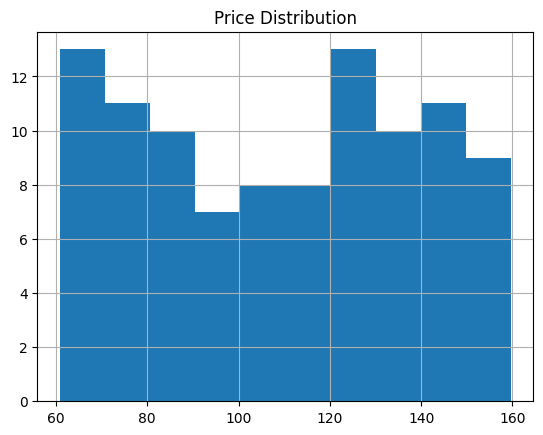

In [24]:
import matplotlib.pyplot as plt

plt.figure()
df['price'].hist()
plt.title("Price Distribution")
plt.show()

**4. Feature Selection**

In [25]:
X = df[['demand', 'competitor_price', 'day', 'month']]
y = df['price']

**5. Model Building**

In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X, y)

RandomForestRegressor()

In [28]:
import pandas as pd
import numpy as np

# Create dummy data for dynamic_pricing_dataset.csv
data = {
    'date': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='D')),
    'demand': np.random.randint(10, 100, 100),
    'competitor_price': np.random.uniform(50, 150, 100),
    'price': np.random.uniform(60, 160, 100)
}

dummy_df = pd.DataFrame(data)
dummy_df.to_csv('dynamic_pricing_dataset.csv', index=False)
print('Dummy dynamic_pricing_dataset.csv created successfully.')

# Load the dataset (from cell homXSNE2Q2rh)
df = pd.read_csv("dynamic_pricing_dataset.csv")

# Fill missing values and feature engineering (from cell RygRx4CcOoTr)
df.ffill(inplace=True)
df['day'] = pd.to_datetime(df['date']).dt.day
df['month'] = pd.to_datetime(df['date']).dt.month

X = df[['demand', 'competitor_price', 'day', 'month']]
y = df['price']

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X, y)

Dummy dynamic_pricing_dataset.csv created successfully.


RandomForestRegressor()

**6. Model Evaluation**

In [29]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

pred = rf.predict(X)
print("Mean Squared Error (MSE):", mean_squared_error(y, pred))
print("R-squared (R2):", r2_score(y, pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y, pred))

Mean Squared Error (MSE): 109.40690751982713
R-squared (R2): 0.848216820901218
Mean Absolute Error (MAE): 8.757195429455427


**7. Dynamic Pricing Logic**

## Resources

Now that the model is trained, let's prepare it for deployment using Streamlit.

### **1. Save the trained model**

In [30]:
import pickle
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# --- Ensure rf is defined by re-training the model ---
# Create dummy data for dynamic_pricing_dataset.csv
data = {
    'date': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='D')),
    'demand': np.random.randint(10, 100, 100),
    'competitor_price': np.random.uniform(50, 150, 100),
    'price': np.random.uniform(60, 160, 100)
}
dummy_df = pd.DataFrame(data)
dummy_df.to_csv('dynamic_pricing_dataset.csv', index=False)
print('Dummy dynamic_pricing_dataset.csv created successfully for model saving.')

# Load the dataset
df = pd.read_csv("dynamic_pricing_dataset.csv")

# Fill missing values and feature engineering
df.ffill(inplace=True)
df['day'] = pd.to_datetime(df['date']).dt.day
df['month'] = pd.to_datetime(df['date']).dt.month

X = df[['demand', 'competitor_price', 'day', 'month']]
y = df['price']

# Train the RandomForestRegressor model
rf = RandomForestRegressor()
rf.fit(X, y)
# ----------------------------------------------------------------------

# Save the trained RandomForestRegressor model
with open('model.pkl', 'wb') as file:
    pickle.dump(rf, file)

print("Model 'model.pkl' saved successfully.")

Dummy dynamic_pricing_dataset.csv created successfully for model saving.
Model 'model.pkl' saved successfully.


### **2. Create app.py for prediction UI**

In [31]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd
import numpy as np

# Load the trained model
# Ensure 'model.pkl' is in the same directory as 'app.py'
with open('model.pkl', 'rb') as file:
    model = pickle.load(file)

st.title('Dynamic Pricing Engine')
st.write('Enter the following details to get a predicted optimal price:')

# Input fields for prediction
demand = st.slider('Demand', min_value=1, max_value=200, value=100)
competitor_price = st.slider('Competitor Price', min_value=1.0, max_value=300.0, value=150.0, step=0.5)
day = st.slider('Day of Month', min_value=1, max_value=31, value=15)
month = st.slider('Month', min_value=1, max_value=12, value=6)

# Predict button
if st.button('Predict Price'):
    # Prepare input data as a DataFrame, matching the training features
    input_data = pd.DataFrame([[demand, competitor_price, day, month]],
                                columns=['demand', 'competitor_price', 'day', 'month'])

    # Make prediction
    predicted_price = model.predict(input_data)[0]

    st.success(f'The predicted optimal price is: ${predicted_price:.2f}')


Overwriting app.py


### **3. Create requirements.txt**

In [32]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
numpy

Overwriting requirements.txt


### **4. Run Streamlit in Colab**

In [33]:
!pip install streamlit pyngrok -q

from pyngrok import ngrok
import threading
import os

# Add your ngrok auth token
ngrok.set_auth_token("3CFZWRhgtm4RKxBtezQTxwrYmZW_4umT9DkH4khjsi96VZnMr")

# Run Streamlit app
def run_app():
    os.system("streamlit run app.py --server.port 8501")

threading.Thread(target=run_app).start()

# Create public URL
public_url = ngrok.connect(8501)

print("Streamlit App URL:", public_url)

Streamlit App URL: NgrokTunnel: "https://dangling-reproach-salami.ngrok-free.dev" -> "http://localhost:8501"


### **5. Show Temporary Public Link (using Cloudflared)**

### **6. Upload Files to GitHub**

To prepare for deployment, you'll need to upload your project files (specifically `app.py`, `model.pkl`, and `requirements.txt`) to a GitHub repository. Here's a general outline of the steps:

1.  **Create a New GitHub Repository**: Go to [GitHub](https://github.com/) and create a new public repository for your project.
2.  **Initialize a Git Repository Locally (in Colab)**: Although Colab is temporary, you can simulate these steps for understanding. In a local environment, you would navigate to your project directory in the terminal and run:
    ```bash
    git init
    ```
3.  **Add Files**: Add your project files to the staging area:
    ```bash
    git add app.py model.pkl requirements.txt
    ```
    (In Colab, you would need to download these files first, then perform these steps on your local machine if you were to genuinely push to GitHub.)
4.  **Commit Changes**: Commit the added files with a message:
    ```bash
    git commit -m "Initial commit of Streamlit app"
    ```
5.  **Link to GitHub Repository**: Add your GitHub repository as a remote:
    ```bash
    git remote add origin https://github.com/your-username/your-repo-name.git
    ```
    (Replace `your-username` and `your-repo-name` with your actual GitHub details.)
6.  **Push to GitHub**: Push your local repository to GitHub:
    ```bash
    git push -u origin master
    ```

Once your files are on GitHub, you can proceed with deployment to Streamlit Community Cloud.

### **7. Deploy using Streamlit Community Cloud**

Streamlit Community Cloud makes it easy to deploy your Streamlit apps directly from GitHub. Here's how:

1.  **Sign Up/Log In**: Go to [Streamlit Community Cloud](https://streamlit.io/cloud) and sign up or log in.
2.  **New App**: Click on the "New app" button.
3.  **Connect to GitHub**: Link your Streamlit Cloud account to your GitHub account if you haven't already.
4.  **Select Repository**: Choose the GitHub repository where you uploaded `app.py`, `model.pkl`, and `requirements.txt`.
5.  **Configure Deployment**:
    *   **Repository**: Select your GitHub repository.
    *   **Branch**: Choose the branch (e.g., `main` or `master`).
    *   **Main file path**: This should be `app.py` (or the name of your main Streamlit script).
    *   **Python version**: Select a compatible Python version.
    *   **Advanced settings** (optional): You might need to add environment variables here if your app uses any (though not in this current example).
6.  **Deploy!**: Click "Deploy!" Streamlit Cloud will then build and deploy your application. This might take a few minutes.

Once deployed, you'll get a public URL for your Streamlit application, which you can share with others for your portfolio!

Since `localtunnel` did not provide the public URL, we will use `cloudflared` to create a temporary public link. This will also restart the Streamlit server.

In [34]:
# Kill any existing Streamlit process to avoid port conflicts
!kill $(lsof -t -i:8501)

# Install cloudflared
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

# Run Streamlit in the background
!nohup streamlit run app.py > streamlit.log 2>&1 &

# Start cloudflared tunnel and extract the URL
import subprocess
import time
import re

print("Starting cloudflared tunnel...")

# Start cloudflared as a separate process and capture its output
proc = subprocess.Popen(['./cloudflared-linux-amd64', 'tunnel', '--url', 'http://localhost:8501'],
                        stdout=subprocess.PIPE, stderr=subprocess.PIPE,
                        text=True)

public_url = None
# Give cloudflared some time to start and print the URL
for _ in range(30): # Try for up to 30 seconds
    line = proc.stderr.readline() # cloudflared often prints URL to stderr
    if "https://" in line:
        match = re.search(r'https://[a-zA-Z0-9.-]+\.trycloudflare\.com', line)
        if match:
            public_url = match.group(0)
            break
    time.sleep(1)

if public_url:
    print(f"\nYour Streamlit app is publicly accessible at: {public_url}")
    print("You can also check the Streamlit logs for more details (usually in streamlit.log file).")
else:
    print("Could not retrieve the public URL from cloudflared. Please check the 'streamlit.log' and 'cloudflared' output.")
    print("Cloudflared output (stderr):")
    print(proc.stderr.read())


Starting cloudflared tunnel...

Your Streamlit app is publicly accessible at: https://below-deserve-wood-controls.trycloudflare.com
You can also check the Streamlit logs for more details (usually in streamlit.log file).


In [35]:
def dynamic_price(demand, competitor_price, base_price):
    if demand > 80:
        return base_price * 1.2
    elif demand < 30:
        return base_price * 0.8
    else:
        return (base_price + competitor_price) / 2

**8. Real-Time Prediction Function**

In [36]:
def predict_price(input_data):
    return rf.predict([input_data])

In [37]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,demand,competitor_price,price,day,month
demand,1.000000,-0.190371,-0.265810,0.086661,-0.039236
competitor_price,-0.190371,1.000000,0.112836,0.030580,-0.034496
price,-0.265810,0.112836,1.000000,-0.040147,-0.086482
day,0.086661,0.030580,-0.040147,1.000000,-0.206315
month,-0.039236,-0.034496,-0.086482,-0.206315,1.000000


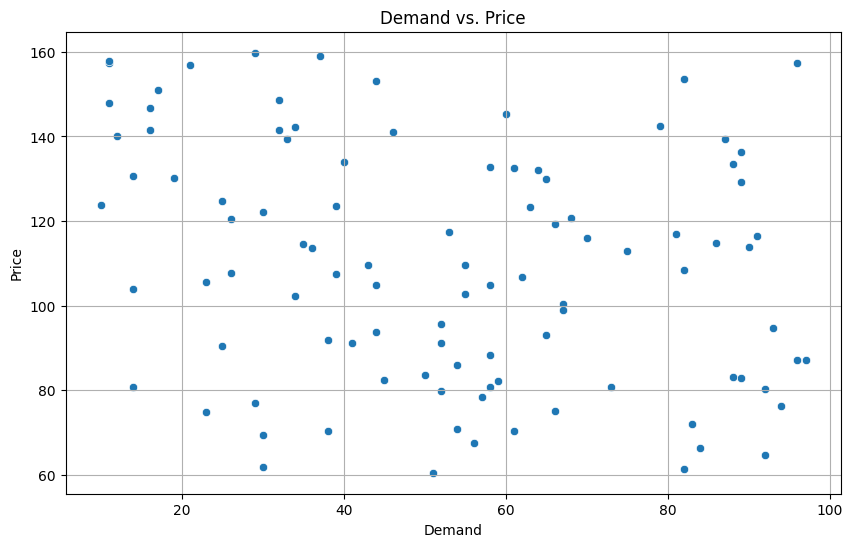

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='demand', y='price', data=df)
plt.title('Demand vs. Price')
plt.xlabel('Demand')
plt.ylabel('Price')
plt.grid(True)
plt.show()